In [12]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
import ssl
import re
from sklearn.feature_extraction.text import CountVectorizer

# Handle SSL for NLTK download
ssl._create_default_https_context = ssl._create_unverified_context
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

sns.set_theme(style="whitegrid")
# Custom colors: Blue for Non-Disaster (0), Red/Orange for Disaster (1)
custom_palette = {'0': "#3498db", '1': "#e74c3c"}

# Load Dataset

In [13]:
df = pd.read_csv('train.csv')
print(df.head())
print(df.info())

   id keyword location                                               text  \
0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   

   target  
0       1  
1       1  
2       1  
3       1  
4       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB
None


# Data Exploration

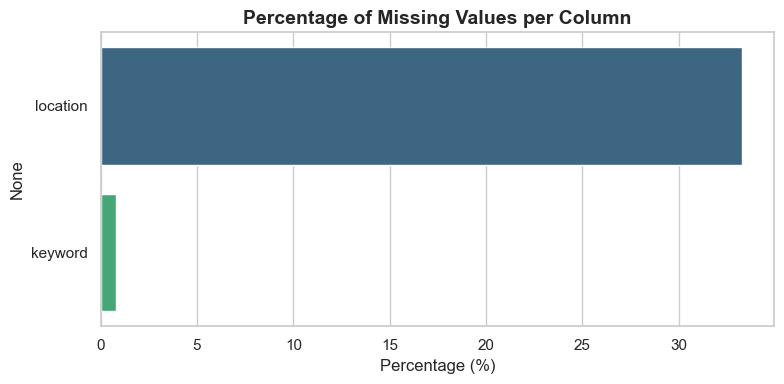

In [14]:
# ==========================================
# 1. MISSING VALUES ANALYSIS
# ==========================================
missing_percentages = (df.isnull().sum() / len(df)) * 100
missing_df = missing_percentages[missing_percentages > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=missing_df.values, y=missing_df.index, hue=missing_df.index, palette="viridis", legend=False)
plt.title('Percentage of Missing Values per Column', fontsize=14, fontweight='bold')
plt.xlabel('Percentage (%)')
plt.tight_layout()
plt.show()

# Target Variable Distribution

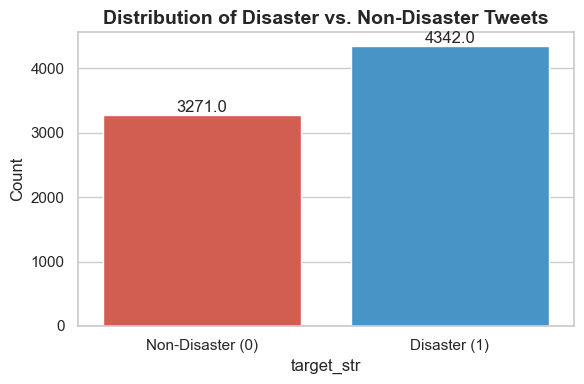

In [15]:
plt.figure(figsize=(6, 4))
df['target_str'] = df['target'].astype(str)
ax = sns.countplot(x='target_str', data=df, hue='target_str', palette=custom_palette, legend=False)
plt.title('Distribution of Disaster vs. Non-Disaster Tweets', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Non-Disaster (0)', 'Disaster (1)'])
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

# Tweet Meta-features

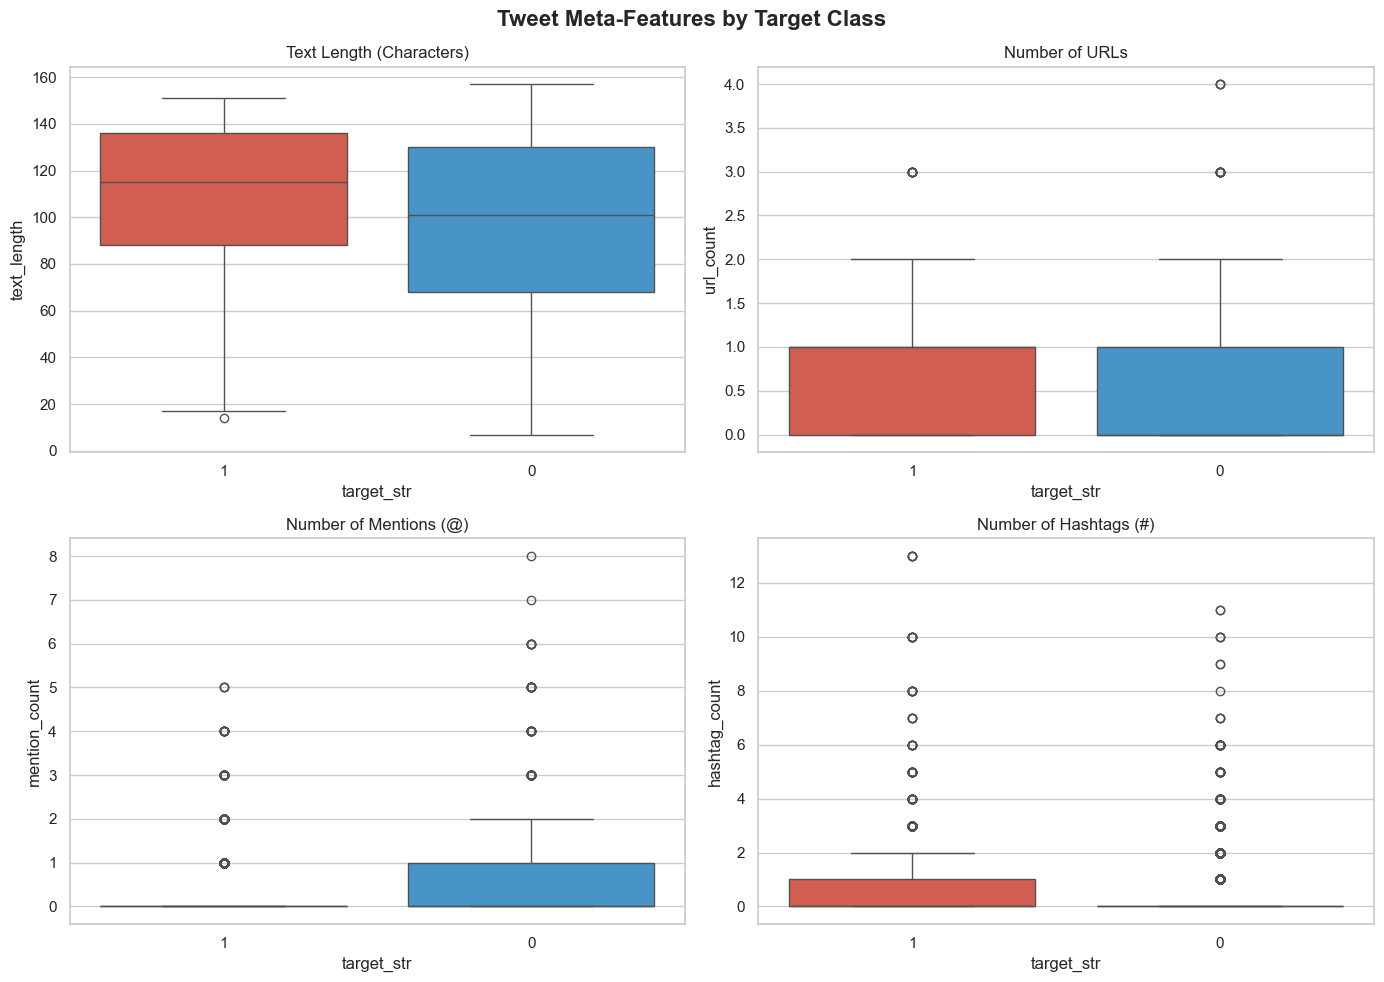

In [16]:
df['url_count'] = df['text'].apply(lambda x: len(re.findall(r'http\S+', x)))
df['mention_count'] = df['text'].apply(lambda x: len(re.findall(r'@\w+', x)))
df['hashtag_count'] = df['text'].apply(lambda x: len(re.findall(r'#\w+', x)))
df['text_length'] = df['text'].apply(len)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Tweet Meta-Features by Target Class', fontsize=16, fontweight='bold')

sns.boxplot(x='target_str', y='text_length', data=df, ax=axes[0,0], hue='target_str', palette=custom_palette, legend=False)
axes[0,0].set_title('Text Length (Characters)')

sns.boxplot(x='target_str', y='url_count', data=df, ax=axes[0,1], hue='target_str', palette=custom_palette, legend=False)
axes[0,1].set_title('Number of URLs')

sns.boxplot(x='target_str', y='mention_count', data=df, ax=axes[1,0], hue='target_str', palette=custom_palette, legend=False)
axes[1,0].set_title('Number of Mentions (@)')

sns.boxplot(x='target_str', y='hashtag_count', data=df, ax=axes[1,1], hue='target_str', palette=custom_palette, legend=False)
axes[1,1].set_title('Number of Hashtags (#)')

plt.tight_layout()
plt.show()

# Keyword Analysis

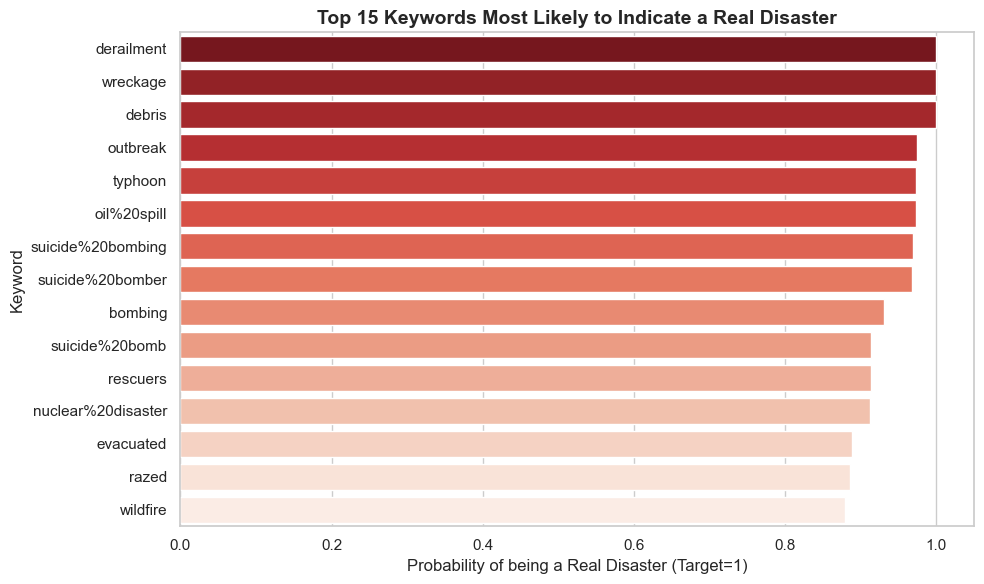

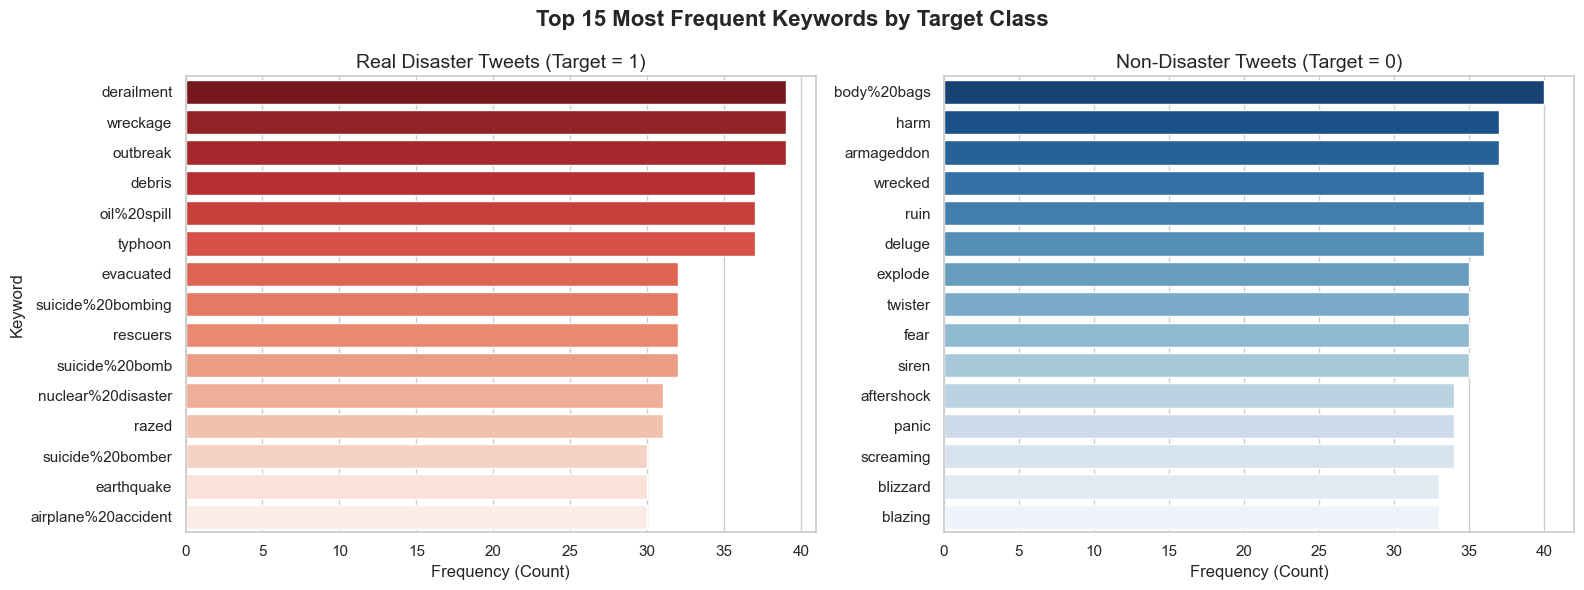

In [17]:
# --- Part A: Probability of being a real disaster ---
keyword_stats = df.groupby('keyword')['target'].agg(['count', 'mean']).reset_index()
# Filter for keywords that appear at least 20 times to avoid outliers
top_prob_keywords = keyword_stats[keyword_stats['count'] >= 20].sort_values(by='mean', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='mean', y='keyword', data=top_prob_keywords, hue='keyword', palette="Reds_r", legend=False)
plt.title('Top 15 Keywords Most Likely to Indicate a Real Disaster', fontsize=14, fontweight='bold')
plt.xlabel('Probability of being a Real Disaster (Target=1)')
plt.ylabel('Keyword')
plt.tight_layout()
plt.show()


# --- Part B: Top 15 Most Frequent Keywords by Target Class ---
# Get the top 15 most frequent keywords for each class
top_15_disaster = df[df['target'] == 1]['keyword'].value_counts().head(15).reset_index()
top_15_disaster.columns = ['keyword', 'count']

top_15_non_disaster = df[df['target'] == 0]['keyword'].value_counts().head(15).reset_index()
top_15_non_disaster.columns = ['keyword', 'count']

# Plot them side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 15 Most Frequent Keywords by Target Class', fontsize=16, fontweight='bold')

# Disaster Keywords (Red)
sns.barplot(x='count', y='keyword', data=top_15_disaster, ax=axes[0], hue='keyword', palette="Reds_r", legend=False)
axes[0].set_title('Real Disaster Tweets (Target = 1)', fontsize=14)
axes[0].set_xlabel('Frequency (Count)')
axes[0].set_ylabel('Keyword')

# Non-Disaster Keywords (Blue)
sns.barplot(x='count', y='keyword', data=top_15_non_disaster, ax=axes[1], hue='keyword', palette="Blues_r", legend=False)
axes[1].set_title('Non-Disaster Tweets (Target = 0)', fontsize=14)
axes[1].set_xlabel('Frequency (Count)')
axes[1].set_ylabel('') # Hide y-label for cleaner look

plt.tight_layout()
plt.show()

# Location Analysis

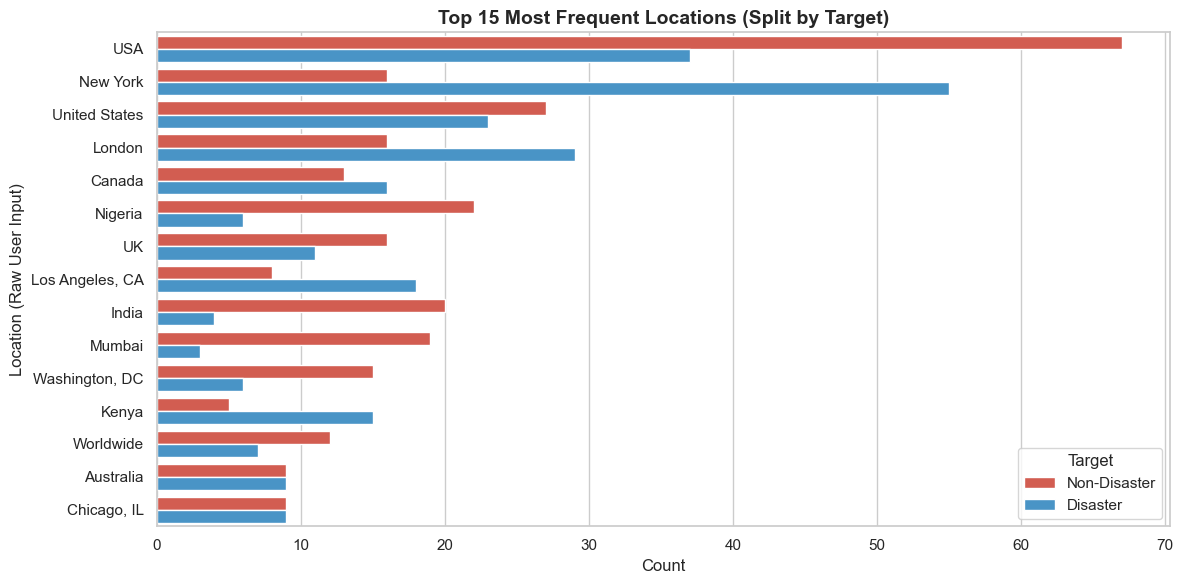

In [18]:
top_15_locations = df['location'].value_counts().head(15).index
plt.figure(figsize=(12, 6))
sns.countplot(y='location', hue='target_str', data=df[df['location'].isin(top_15_locations)], 
              order=top_15_locations, palette=custom_palette)
plt.title('Top 15 Most Frequent Locations (Split by Target)', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Location (Raw User Input)')
plt.legend(title='Target', labels=['Non-Disaster', 'Disaster'])
plt.tight_layout()
plt.show()

# N Gram Frequency

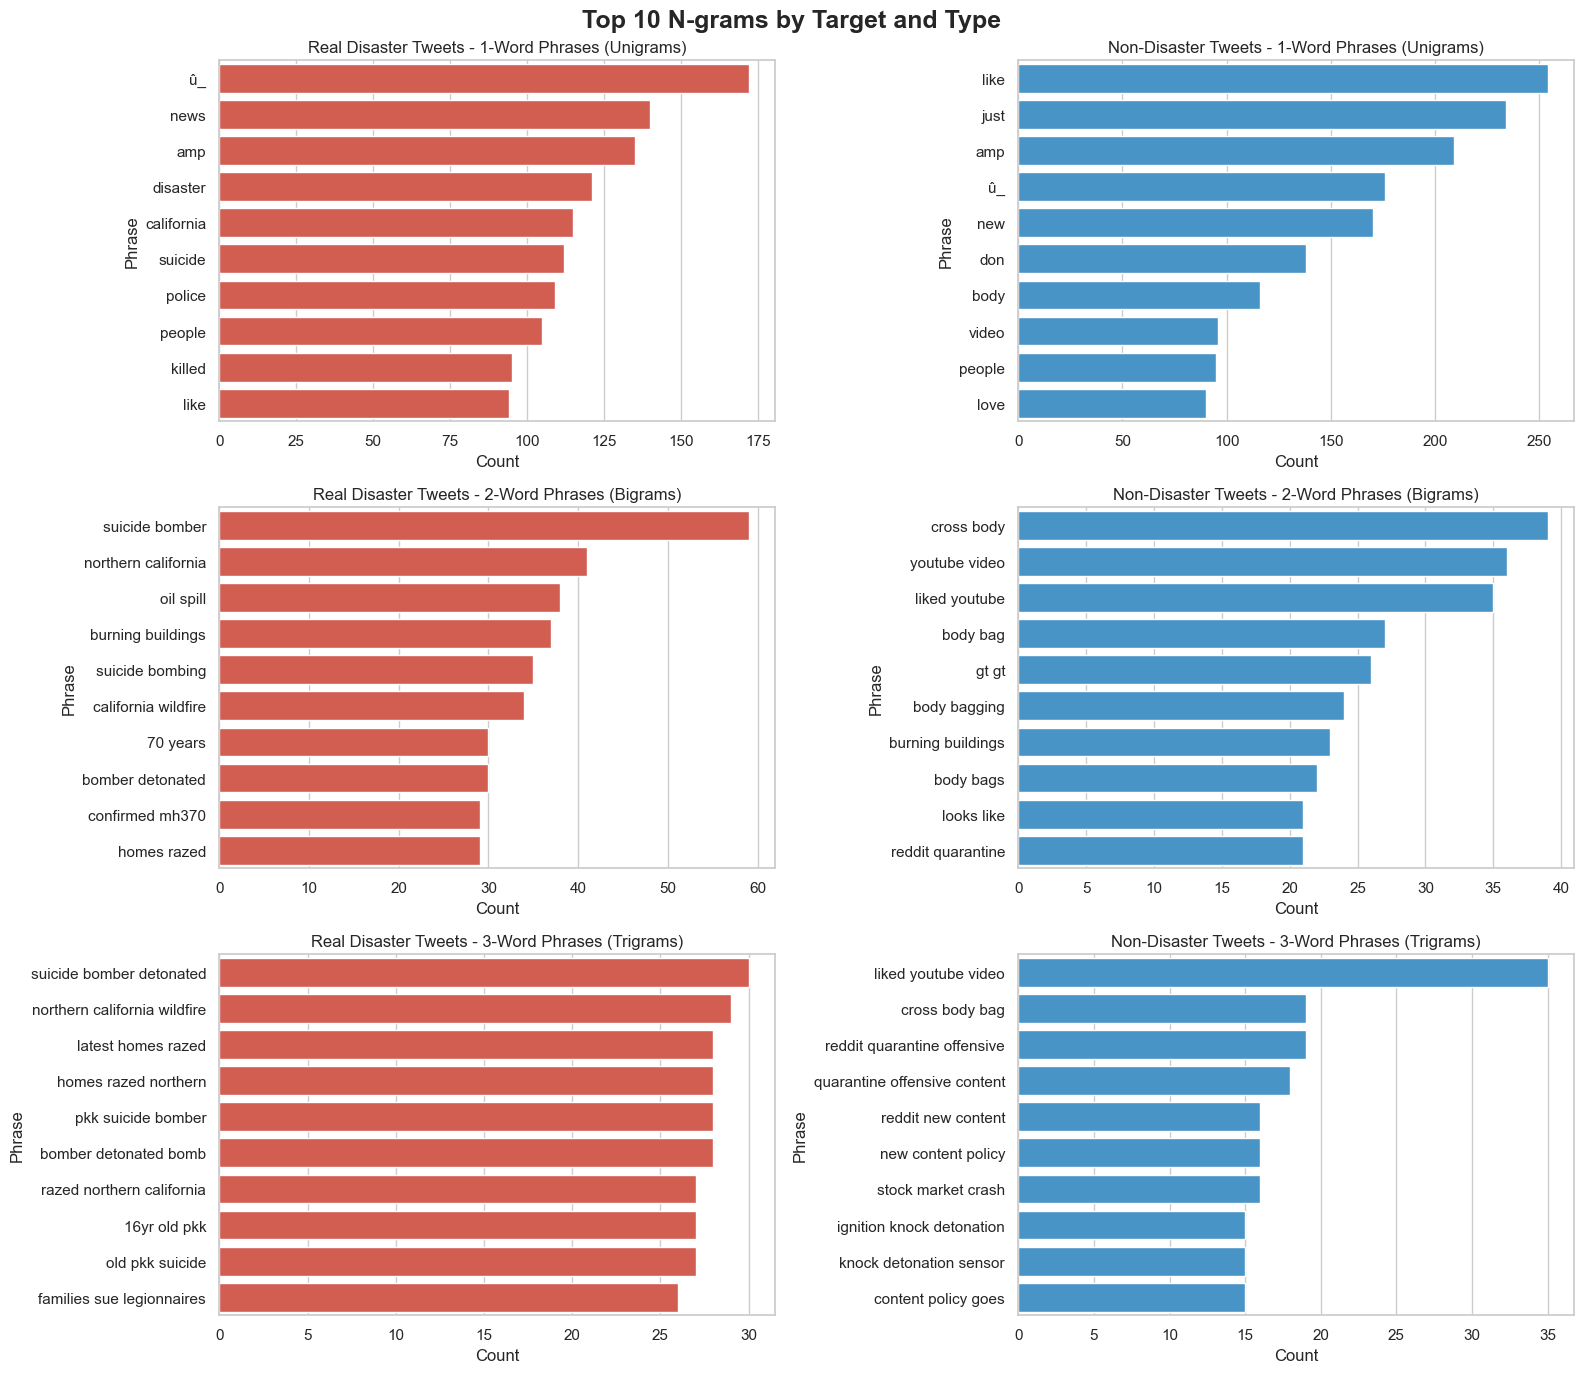

In [19]:
def get_top_ngrams(corpus, n=10, n_gram_range=(1,1)):
    vec = CountVectorizer(ngram_range=n_gram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    # Filter out http and underscore patterns (like 0_)
    words_freq = [(word, count) for word, count in words_freq 
                  if 'http' not in word.lower() and '0_' not in word]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return pd.DataFrame(words_freq[:n], columns=['Phrase', 'Count'])

disaster_texts = df[df['target'] == 1]['text']
non_disaster_texts = df[df['target'] == 0]['text']

# Get unigrams, bigrams, and trigrams
n_grams = [(1, '1-Word Phrases (Unigrams)'), 
           (2, '2-Word Phrases (Bigrams)'), 
           (3, '3-Word Phrases (Trigrams)')]

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Top 10 N-grams by Target and Type', fontsize=18, fontweight='bold')

for idx, (ngram_len, title) in enumerate(n_grams):
    top_ngrams_disaster = get_top_ngrams(disaster_texts, n=10, n_gram_range=(ngram_len, ngram_len))
    top_ngrams_non_disaster = get_top_ngrams(non_disaster_texts, n=10, n_gram_range=(ngram_len, ngram_len))
    
    sns.barplot(x='Count', y='Phrase', data=top_ngrams_disaster, ax=axes[idx, 0], color="#e74c3c")
    axes[idx, 0].set_title(f'Real Disaster Tweets - {title}')
    axes[idx, 0].set_xlabel('Count')
    axes[idx, 0].set_ylabel('Phrase')
    
    sns.barplot(x='Count', y='Phrase', data=top_ngrams_non_disaster, ax=axes[idx, 1], color="#3498db")
    axes[idx, 1].set_title(f'Non-Disaster Tweets - {title}')
    axes[idx, 1].set_xlabel('Count')
    axes[idx, 1].set_ylabel('Phrase')

plt.tight_layout()
plt.show()

# Text Length Analysis

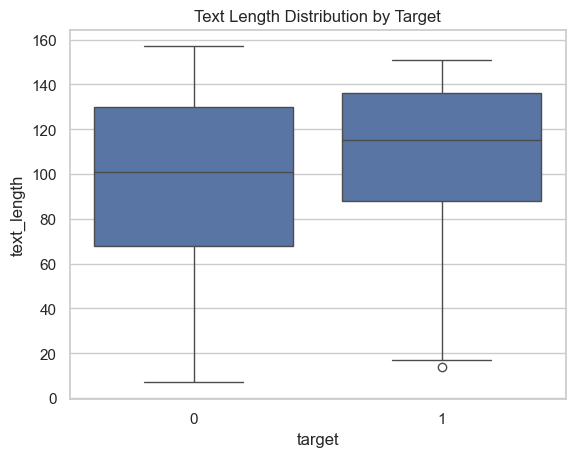

In [20]:
df['text_length'] = df['text'].apply(len)
sns.boxplot(x='target', y='text_length', data=df)
plt.title('Text Length Distribution by Target')
plt.show()

# Word Cloud Generation

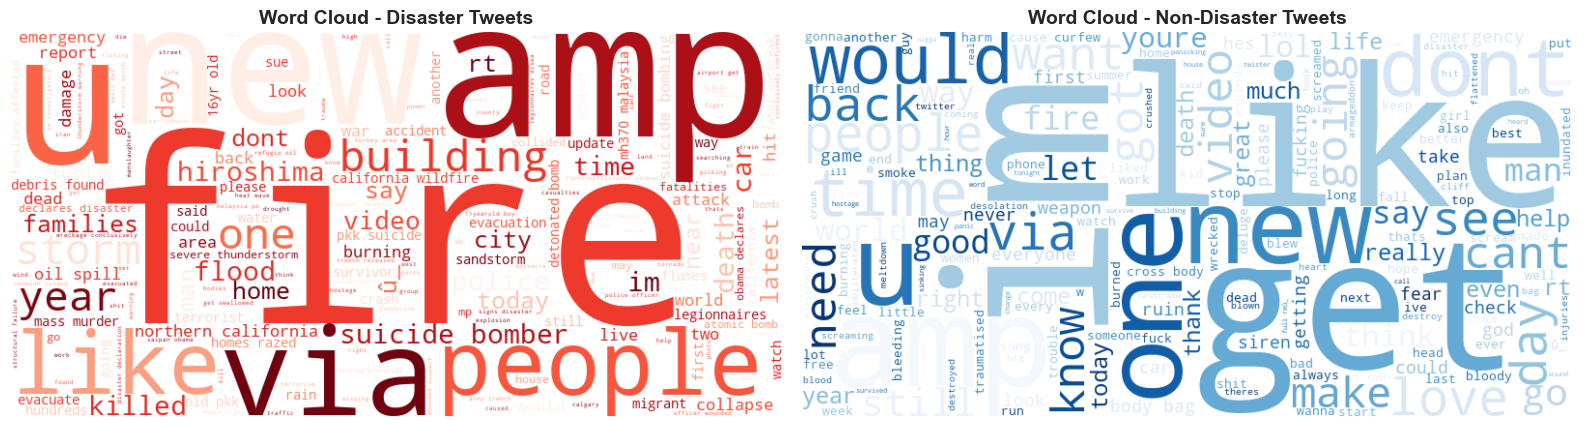

In [21]:
def clean_text(text):
    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'@\w+', '', text)     # remove mentions
    text = re.sub(r'#\w+', '', text)     # remove hashtags
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    text = text.lower()
    return text

disaster_text_clean = ' '.join(df[df['target']==1]['text'].apply(clean_text))
non_disaster_text_clean = ' '.join(df[df['target']==0]['text'].apply(clean_text))

wc_disaster = WordCloud(width=800, height=400, background_color='white', 
                        colormap='Reds', stopwords=stop_words).generate(disaster_text_clean)
wc_non = WordCloud(width=800, height=400, background_color='white', 
                   colormap='Blues', stopwords=stop_words).generate(non_disaster_text_clean)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(wc_disaster, interpolation='bilinear')
axes[0].set_title('Word Cloud - Disaster Tweets', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(wc_non, interpolation='bilinear')
axes[1].set_title('Word Cloud - Non-Disaster Tweets', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()